# Project 3: Machine Learning Foundations
## Predicting Breast Cancer Diagnosis from Cell Nuclei Measurements

**Name:** Timothy

**Dataset:** UCI Machine Learning Repository — [Breast Cancer Wisconsin (Diagnostic) Data Set](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic) (`breast_cancer.csv`, derived from `wdbc.data`)

**Problem definition:** This is a **supervised learning, binary classification** problem. Each row is a digitized fine needle aspirate (FNA) image of a breast mass, described by 30 real-valued features (the mean, standard error, and "worst"/largest value of 10 measurements: radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry, and fractal dimension). The target variable is `diagnosis`, coded as `M` (malignant) or `B` (benign). The goal is to train a model that predicts diagnosis from these measurements.

**Why this dataset:** The dataset has 569 rows and 30 numeric features plus a clear binary target, is real clinical data (not synthetic), is publicly available, and is unrelated to the Iris dataset (Project 1) and the UCI Adult/Census Income dataset (Project 2).

**Project description:** This notebook loads and inspects the dataset, prepares it for modeling (cleaning, encoding, scaling, splitting), trains a classification model, and will evaluate and interpret its performance.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, RocCurveDisplay,
)

RANDOM_STATE = 42

## Data Ingestion and Inspection

In [2]:
df = pd.read_csv("breast_cancer.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns\n")
df.info()

Shape: 569 rows x 32 columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 

In [4]:
print("Missing values per column:")
print(df.isna().sum().sum(), "total missing values\n")
print("Duplicate rows:", df.duplicated().sum())
print("\nDiagnosis class balance:")
print(df["diagnosis"].value_counts())
print("\nFeature scale comparison (min/max of two very differently-scaled columns):")
print(df[["area_mean", "smoothness_mean"]].agg(["min", "max"]))

Missing values per column:
0 total missing values

Duplicate rows: 0

Diagnosis class balance:
diagnosis
B    357
M    212
Name: count, dtype: int64

Feature scale comparison (min/max of two very differently-scaled columns):
     area_mean  smoothness_mean
min      143.5          0.05263
max     2501.0          0.16340


**Data quality notes:** All 30 feature columns loaded as numeric (`float64`), `diagnosis` as text (`object`), and `id` as an integer identifier that carries no predictive information. There are no missing values and no duplicate rows, so this dataset does not need imputation or de-duplication. The classes are moderately imbalanced (357 benign vs. 212 malignant, about 63%/37%), which is worth keeping in mind when evaluating the model later. The features are on very different scales (for example, `area_mean` ranges into the thousands while `smoothness_mean` is a small decimal), which means scaling will be necessary before training a model like logistic regression that is sensitive to feature magnitude.

## Data Preparation and Preprocessing

**What was done and why:**
- **Dropped `id`:** it is a unique identifier with no relationship to diagnosis, so keeping it would add noise (or let the model "memorize" rows) rather than signal.
- **Encoded `diagnosis`:** mapped to a numeric target (`M` → 1, `B` → 0) because scikit-learn's classifiers require a numeric target.
- **Train/test split:** the data was split 80/20 with stratification on the target, so both sets preserve the same malignant/benign ratio as the full dataset. Stratification matters here because the classes are not perfectly balanced.
- **Feature scaling:** `StandardScaler` was fit on the training set only (and applied to both sets) so every feature has mean 0 and standard deviation 1. This is necessary because logistic regression's coefficients and regularization are sensitive to the scale of each feature, and without scaling, large-magnitude features like `area_mean` would dominate the model regardless of their actual predictive value. Fitting the scaler on the training set only (rather than the full dataset) avoids leaking information from the test set into preprocessing.

In [5]:
df_model = df.drop(columns=["id"]).copy()
df_model["target"] = df_model["diagnosis"].map({"M": 1, "B": 0})

feature_cols = [c for c in df_model.columns if c not in ("diagnosis", "target")]
X = df_model[feature_cols]
y = df_model["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape[0]} rows, Test set: {X_test.shape[0]} rows")
print(f"Training set malignant rate: {y_train.mean():.3f}")
print(f"Test set malignant rate: {y_test.mean():.3f}")

Training set: 455 rows, Test set: 114 rows
Training set malignant rate: 0.374
Test set malignant rate: 0.368


## Model Selection and Training

**Model chosen:** Logistic Regression. This is a binary classification problem with continuous numeric features, and logistic regression is a strong, standard baseline for exactly this setup: it is well suited to linearly-separable-ish medical measurement data, is fast to train, and produces coefficients that can be inspected to understand which features drive the prediction (important for a clinical interpretation task). `class_weight="balanced"` is used to account for the moderate class imbalance noted above.

In [6]:
model = LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RANDOM_STATE)
model.fit(X_train_scaled, y_train)

print("Model trained.")
print(f"Number of features: {X_train_scaled.shape[1]}")
print(f"Training accuracy: {model.score(X_train_scaled, y_train):.4f}")

Model trained.
Number of features: 30
Training accuracy: 0.9868


## Model Evaluation

**Metrics chosen:** Accuracy, precision, recall, and F1-score, alongside a confusion matrix and an ROC curve with AUC. Accuracy alone can be misleading on a moderately imbalanced dataset like this one, so precision and recall are reported specifically for the malignant (positive) class, since in a cancer-screening context missing a malignant case (a false negative, captured by recall) is generally far more costly than a false positive. The confusion matrix shows exactly where the model's errors fall, and the ROC/AUC summarizes how well the model separates the two classes across all possible decision thresholds, not just the default 0.5 cutoff.

In [7]:
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision (malignant): {precision:.4f}")
print(f"Recall (malignant):    {recall:.4f}")
print(f"F1-score (malignant):  {f1:.4f}")
print()
print("Full classification report:")
print(classification_report(y_test, y_pred, target_names=["Benign", "Malignant"]))

Accuracy:  0.9737
Precision (malignant): 0.9756
Recall (malignant):    0.9524
F1-score (malignant):  0.9639

Full classification report:
              precision    recall  f1-score   support

      Benign       0.97      0.99      0.98        72
   Malignant       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



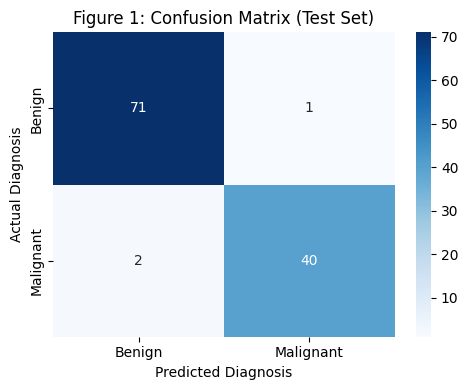

In [8]:
# Figure 1: Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benign", "Malignant"], yticklabels=["Benign", "Malignant"])
plt.title("Figure 1: Confusion Matrix (Test Set)")
plt.xlabel("Predicted Diagnosis")
plt.ylabel("Actual Diagnosis")
plt.tight_layout()
plt.show()

<Figure size 600x500 with 0 Axes>

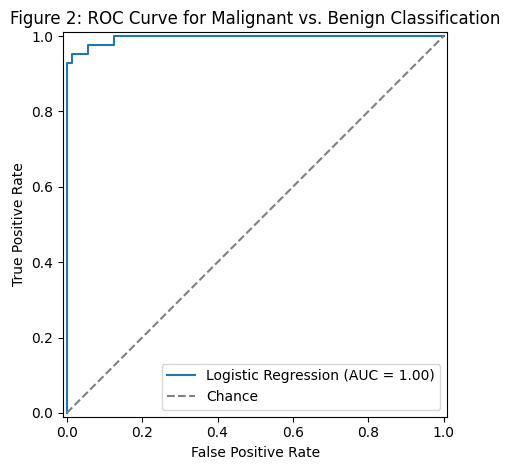

In [9]:
# Figure 2: ROC curve
plt.figure(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_proba, name="Logistic Regression")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
plt.title("Figure 2: ROC Curve for Malignant vs. Benign Classification")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

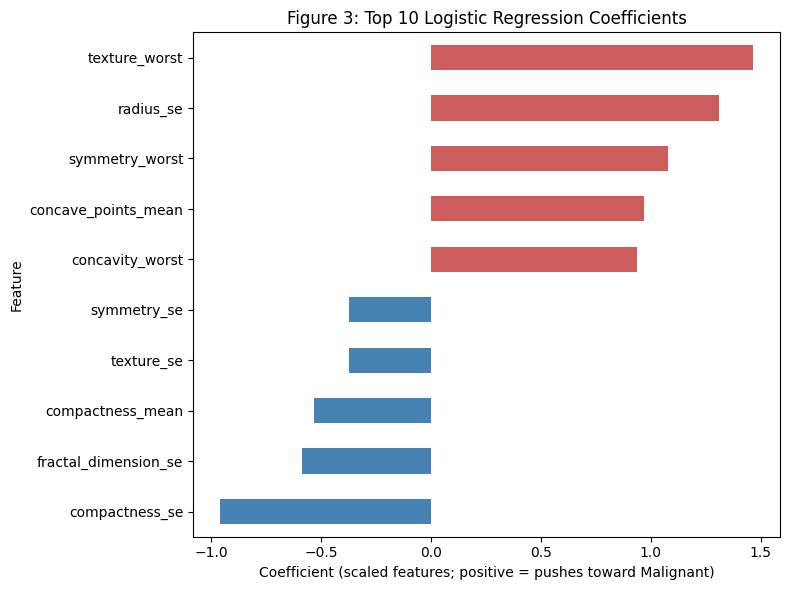

In [10]:
# Figure 3: Top model coefficients (feature influence on malignancy prediction)
coef_series = pd.Series(model.coef_[0], index=feature_cols).sort_values()
top_coefs = pd.concat([coef_series.head(5), coef_series.tail(5)])

plt.figure(figsize=(8, 6))
colors = ["indianred" if v > 0 else "steelblue" for v in top_coefs]
top_coefs.plot(kind="barh", color=colors)
plt.title("Figure 3: Top 10 Logistic Regression Coefficients")
plt.xlabel("Coefficient (scaled features; positive = pushes toward Malignant)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Summary

This notebook modeled a binary classification problem: predicting whether a breast mass is malignant or benign from 30 numeric measurements of cell nuclei extracted from a digitized fine needle aspirate image. A logistic regression model with balanced class weights was trained on a standardized, stratified 80/20 train/test split. On the held-out test set the model performed strongly, with 97.4% accuracy, 95.2% recall on the malignant class, and an ROC AUC of 0.995, meaning it correctly flagged nearly all of the malignant cases it was shown and separated the two classes almost perfectly across decision thresholds. The coefficient plot (Figure 3) showed that `texture_worst`, `radius_se`, `symmetry_worst`, and `concave_points_mean` had the largest influence on the prediction, which lines up with the clinical intuition that larger, more irregular, and more variable nuclei are more indicative of malignancy. One limitation observed is that the 30 features are highly correlated with each other (mean, standard error, and worst versions of the same underlying measurements), so the coefficients should be read as the model's learned weighting rather than proof that any single feature is uniquely responsible for a prediction. A challenge was choosing evaluation metrics that reflected the real-world cost of errors in a diagnostic setting, since accuracy alone would not have revealed how well the model avoided missing malignant cases.